In [4]:
import sys 
import os 

sys.path.append("/Users/zacharykelly/Documents/MATLAB/projects/lightLoggerAnalysis/code/library/matlabIO/python_libraries")
sys.path.append("/Users/zacharykelly/Documents/MATLAB/projects/lightLoggerAnalysis/code/library/sensor_utility/")
import world_util
import chunk_io
import video_io
import matplotlib.pyplot as plt
import numpy as np
from natsort import natsorted 
import pandas as pd

In [5]:
folder_path: str = "/Volumes/T7 Shield/settingsAgain"

In [8]:
def get_last_world_chunk(chunks):
    for idx, chunk in enumerate(chunks):
        if(len(chunk['W']['v']) == 0):
            return chunks[idx - 3]
        

1/10


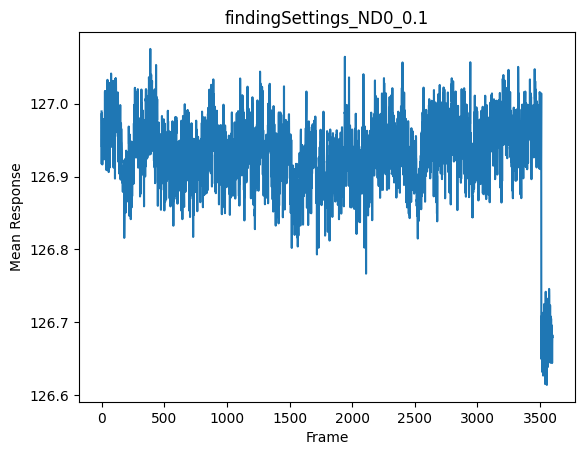

2/10


In [ ]:
filenames: list[str] = [ filename for filename in os.listdir(folder_path) if filename]
settings: list[np.ndarray] = []

for idx, folder in enumerate(natsorted(filenames)):
    print(f"{idx + 1}/{len(os.listdir(folder_path))}")

    # Parse the chunks of this folder
    chunks: list[dict] = chunk_io.parse_chunks(os.path.join(folder_path, folder), apply_digital_gain=True)
    last_chunk: dict = get_last_world_chunk(chunks)

    # Plot the world camera results 
    plt.title(folder)
    plt.plot(np.mean(last_chunk['W']['v'], axis=(1, 2)))

    plt.ylabel("Mean Response")
    plt.ylim([0, 255])
    plt.xlabel("Frame")

    plt.show() 

    # Save the settings 
    settings.append(last_chunk['W']['t'])

    


